# 2 · Eigenvalues and mode shapes

**Math primer — notebook 2 of 7.**

We have $[M]\{\ddot q\}+[K]\{q\}=\{0\}$. Now: what does the system do when you let
go of it?

**You should come out knowing:** what a mode shape *is* physically, why the
eigenproblem is $\left([K]-\omega^2[M]\right)\{u\}=0$ rather than the plain
$[A]\{u\}=\lambda\{u\}$, that mode shapes have arbitrary scale, and what goes
wrong when two natural frequencies coincide.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
import primer
from primer import SERIES, INK, INK2, GRID, tidy
primer.use_style()

## 2.1 · Guess a solution

Try the guess that every coordinate oscillates at the *same* frequency and in
*fixed proportion* — that is, the shape does not change, only its amplitude:

$$\{q(t)\} = \{u\}\cos\omega t$$

Then $\{\ddot q\} = -\omega^2\{u\}\cos\omega t$, and substituting:

$$\left(-\omega^2[M]+[K]\right)\{u\}\cos\omega t = \{0\}$$

which must hold at every instant, so

$$\boxed{\left([K]-\omega^2[M]\right)\{u\}=\{0\}}$$

This is the paper's Eq. (3). It is a **generalised** eigenproblem: the $[M]$ sits
where the identity matrix sits in the textbook $[A]\{u\}=\lambda\{u\}$. That is
not cosmetic — it is why the orthogonality in notebook 3 is with respect to $[M]$
rather than the plain dot product.

A non-zero $\{u\}$ exists only if the matrix is singular:

$$\det\left([K]-\omega^2[M]\right)=0$$

which is a polynomial in $\omega^2$ of degree $n$. Its $n$ roots are the natural
frequencies.

In [2]:
m1, m2 = 2.0, 1.0
k1, k2 = 800.0, 400.0
M = np.diag([m1, m2])
K = np.array([[k1 + k2, -k2], [-k2, k2]])

# --- the determinant route, done explicitly -------------------------------
# det(K - s M) = (k1+k2 - s m1)(k2 - s m2) - k2^2  = a s^2 + b s + c,  s = w^2
a = m1 * m2
b = -((k1 + k2) * m2 + k2 * m1)
c = (k1 + k2) * k2 - k2 ** 2
roots = np.roots([a, b, c])
print("roots of the characteristic polynomial, s = w^2:", np.sort(roots))
print("natural frequencies [rad/s]:", np.sqrt(np.sort(roots)))
print("natural frequencies [Hz]   :", np.sqrt(np.sort(roots)) / (2 * np.pi))

roots of the characteristic polynomial, s = w^2: [200. 800.]
natural frequencies [rad/s]: [14.1421 28.2843]
natural frequencies [Hz]   : [2.2508 4.5016]


In [3]:
# --- and the way you will actually do it ----------------------------------
w2, V = eigh(K, M)          # solves K u = w^2 M u
omega = np.sqrt(w2)
print("eigh gives w^2 =", w2)
print("agrees with the polynomial?", np.allclose(np.sort(w2), np.sort(roots)))
print("\nmode shapes (columns):\n", V)

eigh gives w^2 = [200. 800.]
agrees with the polynomial? True

mode shapes (columns):
 [[-0.4082 -0.5774]
 [-0.8165  0.5774]]


## 2.2 · Reading a mode shape

`eigh` returns the modes mass-normalised ($\{u\}^\mathsf{T}[M]\{u\}=1$), which is
convenient but hides the physical picture. Rescale so the largest component is
$+1$ and the shapes become readable:

mode 1:  f =   2.25 Hz   shape = [0.5 1. ]
mode 2:  f =   4.50 Hz   shape = [ 1. -1.]


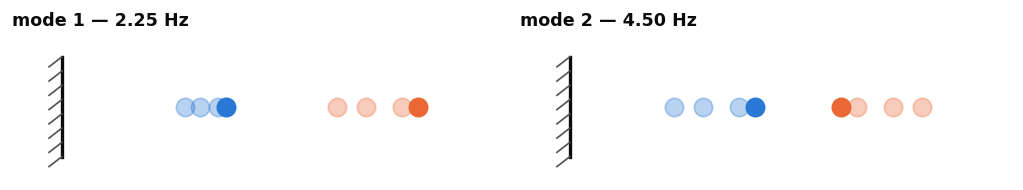

In [4]:
Vs = V / V[np.argmax(np.abs(V), axis=0), np.arange(V.shape[1])]
for r in range(2):
    print(f"mode {r+1}:  f = {omega[r]/2/np.pi:6.2f} Hz   shape = {Vs[:, r]}")

fig, axes = plt.subplots(1, 2, figsize=(8.6, 1.9))
for r, ax in enumerate(axes):
    primer.strobe(ax, Vs[:, r], amp=0.30,
                  title=f"mode {r+1} — {omega[r]/2/np.pi:.2f} Hz")
plt.tight_layout(); plt.show()

The faded dots are the masses at several phases of one cycle; the solid dots are
the extreme. Mode 1: both masses move the same way, the light one further. Mode
2: they move in opposite directions.

That is all a mode shape is — **the fixed ratio in which the coordinates move
when the system is left to vibrate at one of its natural frequencies.**

### Scale is arbitrary

In [5]:
u = V[:, 0]
for s in (1.0, -3.7, 0.02):
    resid = (K - w2[0] * M) @ (s * u)
    print(f"scaling by {s:6.2f}: residual norm = {np.linalg.norm(resid):.2e}")
print("\nAny multiple of a mode shape is still a mode shape. Only the RATIO is physical.")
print("Which is why every convention (unit largest entry, unit norm, mass-normalised)")
print("is equally valid -- and why you must always say which one you used.")

scaling by   1.00: residual norm = 3.43e-14
scaling by  -3.70: residual norm = 1.60e-13
scaling by   0.02: residual norm = 3.97e-16

Any multiple of a mode shape is still a mode shape. Only the RATIO is physical.
Which is why every convention (unit largest entry, unit norm, mass-normalised)
is equally valid -- and why you must always say which one you used.


## 2.3 · Watching the modes appear

A useful intuition: sweep a parameter and watch the frequencies and the shapes
move. Here we soften the coupling spring $k_2$ toward zero.

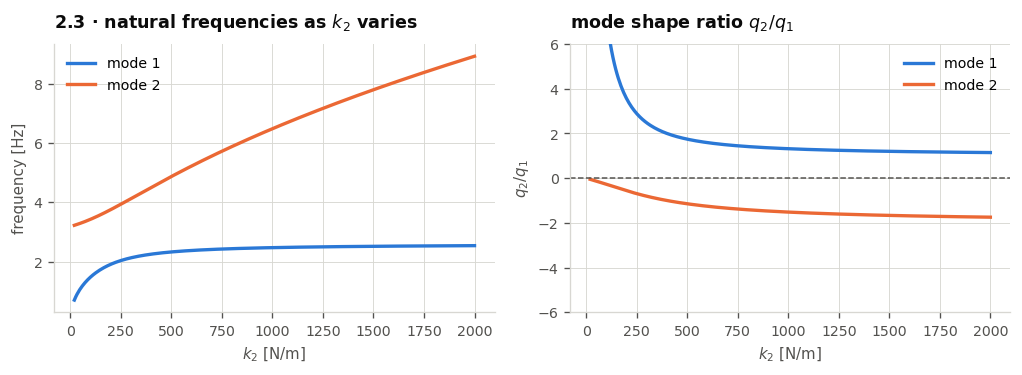

In [6]:
k2s = np.linspace(20, 2000, 300)
fs = np.zeros((k2s.size, 2))
ratio = np.zeros((k2s.size, 2))
for i, kk in enumerate(k2s):
    Ki = np.array([[k1 + kk, -kk], [-kk, kk]])
    wi, Vi = eigh(Ki, M)
    fs[i] = np.sqrt(wi) / (2 * np.pi)
    ratio[i] = Vi[1] / Vi[0]          # q2/q1 for each mode

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.2))
axes[0].plot(k2s, fs[:, 0], color=SERIES[0], label="mode 1")
axes[0].plot(k2s, fs[:, 1], color=SERIES[1], label="mode 2")
tidy(axes[0], "2.3 · natural frequencies as $k_2$ varies", "$k_2$ [N/m]", "frequency [Hz]")
axes[0].legend()

axes[1].plot(k2s, ratio[:, 0], color=SERIES[0], label="mode 1")
axes[1].plot(k2s, ratio[:, 1], color=SERIES[1], label="mode 2")
axes[1].axhline(0, color=INK2, lw=0.9, ls="--")
axes[1].set_ylim(-6, 6)
tidy(axes[1], "mode shape ratio $q_2/q_1$", "$k_2$ [N/m]", "$q_2/q_1$")
axes[1].legend()
plt.tight_layout(); plt.show()

Mode 1 always has $q_2/q_1 > 0$ (in phase), mode 2 always $< 0$ (out of phase),
and the two frequency curves never touch. That last point matters.

## 2.4 · When two frequencies coincide

If $\omega_1 = \omega_2$, the matrix $[K]-\omega^2[M]$ drops rank by two, and
**any** vector in a two-dimensional subspace is a valid mode shape. The mode
shapes are no longer determined by the system — only the subspace is.

This is not a curiosity. The paper spends Eqs. (17)–(19) proving that its design
does *not* land in this case, because if it did, "make mode 2 orthogonal to the
excitation" would be a statement about a shape that is not uniquely defined.

In [7]:
# force a degenerate system: two identical uncoupled oscillators
Md = np.diag([1.0, 1.0])
Kd = np.diag([500.0, 500.0])
wd, Vd = eigh(Kd, Md)
print("frequencies [Hz]:", np.sqrt(wd) / 2 / np.pi)
print("shapes returned by eigh:\n", Vd)

# but an arbitrary rotation of those two vectors works just as well
th = 0.7
Rot = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
Valt = Vd @ Rot
print("\na rotated pair, equally valid:\n", Valt)
for r in range(2):
    print(f"  residual for rotated mode {r+1}: "
          f"{np.linalg.norm((Kd - wd[r]*Md) @ Valt[:, r]):.2e}")
print("\nThe subspace is determined; the individual shapes are not.")

frequencies [Hz]: [3.5588 3.5588]
shapes returned by eigh:
 [[1. 0.]
 [0. 1.]]

a rotated pair, equally valid:
 [[ 0.7648 -0.6442]
 [ 0.6442  0.7648]]
  residual for rotated mode 1: 0.00e+00
  residual for rotated mode 2: 0.00e+00

The subspace is determined; the individual shapes are not.


**Practical rule:** whenever you write code that depends on a particular mode
shape — as the paper's design does — check that the corresponding eigenvalue is
well separated from its neighbours. In `orthomount` that check is the assertion
that $K_{\phi\phi}/K_{\psi\psi} \ne I_x/I_z$, which is exactly the paper's
Eq. (19) argument.

---

**Next:** [3 · Orthogonality and modal coordinates](03_orthogonality.ipynb)